# **Benchmark SPECTRA**

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os, sys, json, gc, warnings
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import math

warnings.filterwarnings('ignore')

In [3]:
# Paths
BASE_DIR = "/scratch/michele.calabro/gears/VCC/SPECTRA"

DATASET_SIZE = "5k"
RUNS = list(range(10)) #TODO: for now just one run for testing
MODELS = ["SPECTRA", "baseline", "scLambda", "GEARS"]
MODEL_DIR = f"{BASE_DIR}/results/final_vcc"
GT_PATH = f"{MODEL_DIR}/test_cells_vcc.h5ad"

# Define where to save/load our cache
CACHE_FILE = f"{BASE_DIR}/benchmark/results/benchmark_cache_{DATASET_SIZE}.csv"
RESULTS_CSV = f"{BASE_DIR}/benchmark/results/full_comparison_{DATASET_SIZE}.csv"
os.makedirs(os.path.dirname(RESULTS_CSV), exist_ok=True)

# plots
PLOTS_FOLDER = f"{BASE_DIR}/benchmark/results/plots"
os.makedirs(PLOTS_FOLDER, exist_ok=True)

I mean, thsi is COMPLETELY useles...

In [4]:
def get_h5ad_path(model, run_id):
    '''
    returns path of h5ad
    '''
    base = MODEL_DIR
    return f"{base}/pred_adata-{model}-{run_id}.h5ad"

In [5]:
# summary of available datasets
status = []
for m in MODELS:
    for r in RUNS:
        p = get_h5ad_path(m, r)
        status.append({"Model": m, "Run": r, "Exists": os.path.exists(p)})

df_status = pd.DataFrame(status)
summary = df_status.groupby('Model')['Exists'].agg(['sum', 'count'])
summary.columns = ['Available', 'Expected']
summary['%'] = (100 * summary['Available'] / summary['Expected']).round(0).astype(int)

print("Data Availability:")
display(summary)

Data Availability:


,Available,Expected,%
Model,,,
GEARS,10,10,100
SPECTRA,10,10,100
baseline,10,10,100
scLambda,10,10,100


In [6]:
# ═══════════════════════════════════════════════════════════════════════
# Load control cells
# ═══════════════════════════════════════════════════════════════════════

print("Loading control cells for DES calculation...")
base_adata = sc.read_h5ad(f"{MODEL_DIR}/control_test_cells_vcc.h5ad")
CTRL_CELLS = base_adata[base_adata.obs['target_gene'] == 'non-targeting']
CTRL_CELLS.X = CTRL_CELLS.X.toarray() if sp.issparse(CTRL_CELLS.X) else CTRL_CELLS.X
del base_adata

print(f"Extracted {len(CTRL_CELLS)} control cells.")

Loading control cells for DES calculation...
Extracted 5160 control cells.


In [7]:
# Load WMSE Weights
import pickle
weights_path = '/scratch/michele.calabro/gears/VCC/SPECTRA/data/gene_weights-vcc_BENCHMARK.pkl'
if os.path.exists(weights_path):
    print('found already existing gene weights dictionary! Loading...')
    with open(weights_path, 'rb') as f:
        gene_weights = pickle.load(f)
else:
    print('No gene weights dictionary found')

found already existing gene weights dictionary! Loading...


In [8]:
def calc_wmse(adata_true, adata_pred, weights_dict: dict):
    """
    Calculate one weighted MSE value for each target gene p.
    """
    assert set(adata_true.var_names) == set(adata_pred.var_names), "genes set not matching"
    assert set(adata_true.obs['target_gene'].unique()) == set(adata_pred.obs['target_gene'].unique()), "perturbations set not matching"

    wmse_results = {}
    
    # Extract unique target genes from the true dataset
    target_genes = adata_true.obs['target_gene'].unique().tolist()
    #target_genes.remove('non-targeting')
    
    for p in target_genes:

        # Create boolean masks to subset cells for target gene 'p'
        mask_true = adata_true.obs['target_gene'] == p
        mask_pred = adata_pred.obs['target_gene'] == p
        
        # Calculate mu^p (True mean) and mu_hat^p (Predicted mean) across cells (axis=0)
        mu_p = np.asarray(adata_true[mask_true].X.mean(axis=0)).flatten()
        mu_hat_p = np.asarray(adata_pred[mask_pred].X.mean(axis=0)).flatten()
        
        # Retrieve the weight vector for 'p' and ensure it's a numpy array
        w = np.asarray(weights_dict[p])
        
        # Apply the formula: sum(w_i * (mu_i - mu_hat_i)^2)
        squared_diff = (mu_p - mu_hat_p) ** 2
        wmse = np.sum(w * squared_diff)
        
        # Store the result
        wmse_results[p] = wmse
        
    return wmse_results

In [9]:
# ═══════════════════════════════════════════════════════════════════════
# Core Evaluation Engine
# ═══════════════════════════════════════════════════════════════════════

# this contains all the metrics functions
from spectra.evaluation import *

def _mean_of_dict(d):
    """
    Helper to safely average the per-perturbation dictionaries returned by the metric functions.
    """
    if not d: return np.nan
    vals = [v for v in d.values() if pd.notnull(v)]
    return np.mean(vals) if vals else np.nan


def evaluate_single_run(model, run_id, gt_path, top_DEGs=None, gene_weights=gene_weights):

    pred_path = get_h5ad_path(model, run_id)
    row = {"Model": model, "Run": run_id}
    
    CORE_METRICS = {
        "WMSE": np.nan, 
        "MSE": np.nan, 
        "Pearson distance": np.nan, 
        "F1": np.nan, 
        "Precision": np.nan, 
        "Common_DEGs": np.nan,
        "Wasserstein distance": np.nan, 
        "kldiv":np.nan, 
        "AUPRC": np.nan, 
        "E Distance": np.nan
    }
    
    if not os.path.exists(pred_path):
        raise ValueError(f"file at {pred_path} does not exists")
    if not os.path.exists(gt_path):
        raise ValueError(f"file at {gt_path} does not exists")
    
    try:
        adata_pred = sc.read_h5ad(pred_path)
        adata_true = sc.read_h5ad(gt_path)

        assert set(adata_true.obs['target_gene'].unique())== set(adata_pred.obs['target_gene'].unique()), "perturbations not matching"
        
        # conditions = adata_true.obs['target_gene'].unique().tolist()
        adata_true.obs['target_gene'] = adata_true.obs['target_gene'].astype('category')
        adata_pred.obs['target_gene'] = adata_pred.obs['target_gene'].astype('category')
        
        row["WMSE"] = _mean_of_dict(calc_wmse(adata_true, adata_pred, gene_weights))
        row["MSE"] = _mean_of_dict(calc_mse(adata_true, adata_pred, n_top_degs=top_DEGs))
        # row["Pearson_distance"] = _mean_of_dict(calc_pcc_delta(adata_true, adata_pred, n_top_degs=top_DEGs))
        row["Wasserstein_distance"] = _mean_of_dict(calc_wasserstein(adata_true, adata_pred, n_top_degs=top_DEGs))
        row["kldiv"] = _mean_of_dict(calc_kldiv(adata_true, adata_pred, n_top_degs=top_DEGs))
        row["E_Distance"] = _mean_of_dict(calc_edistance(adata_true, adata_pred, n_top_degs=top_DEGs))

         # NOTE: adding control for DES metrics (control are not considered when calcualting non DES scores)
        adata_true = sc.concat([adata_true, CTRL_CELLS], join='inner')
        adata_pred = sc.concat([adata_pred, CTRL_CELLS], join='inner')

        row["AUPRC"] = _mean_of_dict(calc_auprc(adata_true, adata_pred))
        row["DES_F1"] = _mean_of_dict(calc_f1(adata_true, adata_pred))
        row["DES_Precision"] = _mean_of_dict(calc_precision(adata_true, adata_pred))
        # row["Common_DEGs"] = _mean_of_dict(calc_common_degs(adata_true, adata_pred))
        row["Status"] = "OK"
        
        del adata_true, adata_pred
        gc.collect()
        
    except Exception as e:
        row["Status"] = f"Error: {str(e)}"
        for k in CORE_METRICS:
            if k not in row: row[k] = np.nan
            
    return row

In [10]:
import concurrent.futures

TOP_DEGS = None

cached_results = []
tasks_to_run = []
if os.path.exists(CACHE_FILE):
    df_cache = pd.read_csv(CACHE_FILE)
    print(f"📦 Found existing cache with {len(df_cache)} records at:\n   {CACHE_FILE}")
else:
    df_cache = pd.DataFrame()
    print("📦 No existing cache found. Starting fresh.")

# Filter Tasks (Only run what is missing or previously failed)
for m in MODELS:
    for r in RUNS:
        # Check if this exact run is already in the cache AND succeeded
        if not df_cache.empty:
            mask = (
                (df_cache['Model'] == m) & 
                (df_cache['Run'] == r) & 
                (df_cache['Status'] == 'OK')
            ) # mask is a boolean pandas Series (true/false for each row of df_cache)
            if mask.any():
                # It's already done! Add it to our completed pile.
                cached_results.append(df_cache[mask].iloc[0].to_dict())
                continue
        
        # If not found or not 'OK', add it to the compute queue
        tasks_to_run.append((m, r))

# Define the Worker
def parallel_worker(model, run_id):
    """Worker function executed by each CPU core."""
    old_stdout, old_stderr = sys.stdout, sys.stderr
    with open(os.devnull, 'w') as devnull:
        sys.stdout = devnull
        sys.stderr = devnull
        try:
            result = evaluate_single_run(model, run_id, gt_path=GT_PATH, top_DEGs=TOP_DEGS)
        finally:
            sys.stdout = old_stdout
            sys.stderr = old_stderr
    return result

# Execute Missing Tasks using concurrent.futures
new_results = []
if tasks_to_run:
    print(f"\n🚀 Running {len(tasks_to_run)} missing tasks on 16 CPUs...")
    
    # Initialize the Process Pool
    with concurrent.futures.ProcessPoolExecutor(max_workers=16) as executor:
        # Submit all tasks to the executor
        futures = [executor.submit(parallel_worker, m, r) for m, r in tasks_to_run]
        
        # Wrap as_completed with tqdm to keep the progress bar updated
        for future in tqdm(concurrent.futures.as_completed(futures), total=len(tasks_to_run), desc="Evaluating Runs"):
            new_results.append(future.result())
else:
    print("\n✅ All tasks are already cached! Skipping heavy computation.")

# 5. Compile, Save, and Output
all_results = cached_results + new_results
df = pd.DataFrame(all_results)

if not df.empty:
    
    # Save the updated cache to disk
    os.makedirs(os.path.dirname(CACHE_FILE), exist_ok=True)
    df.to_csv(CACHE_FILE, index=False)
    print(f"\n💾 Master cache updated and saved!")
    
    display(df.head())
else:
    print("\n[!] DataFrame is empty. All workers failed.")

📦 No existing cache found. Starting fresh.

🚀 Running 40 missing tasks on 16 CPUs...


Evaluating Runs:   0%|          | 0/40 [00:00<?, ?it/s]WARNING:2026-07-17 10:49:49,617:jax._src.xla_bridge:876: An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


Evaluating Runs:  20%|██        | 8/40 [20:17<17:43, 33.23s/it]     

Evaluating Runs:  22%|██▎       | 9/40 [20:21<12:28, 24.14s/it]

Evaluating Runs:  25%|██▌       | 10/40 [20:22<08:32, 17.07s/it]

...

Evaluating Runs:  78%|███████▊  | 31/40 [41:57<00:58,  6.46s/it]

Evaluating Runs:  80%|████████  | 32/40 [41:57<00:38,  4.87s/it]

Evaluating Runs: 100%|██████████| 40/40 [52:49<00:00, 79.25s/it] 



💾 Master cache updated and saved!


,Model,Run,WMSE,MSE,Wasserstein_distance,kldiv,E_Distance,AUPRC,DES_F1,DES_Precision,Status
0,baseline,0,0.468127,0.002760,220.701465,46.085235,9.110590,0.088072,0.023236,0.039000,OK
1,baseline,4,0.468127,0.002760,220.701465,46.085235,9.110590,0.088072,0.023236,0.039000,OK
2,SPECTRA,7,0.091109,0.004425,234.787560,37.495750,5.897145,0.089230,0.100235,0.075972,OK
3,SPECTRA,9,0.090407,0.004405,234.690220,37.468335,5.900675,0.089316,0.099374,0.075564,OK
4,SPECTRA,0,0.091241,0.004425,234.803785,37.475310,5.907585,0.088962,0.099942,0.076020,OK


In [16]:
display(df.head())

,Model,Run,WMSE,MSE,Wasserstein_distance,AUPRC,DES_F1,Common_DEGs,Status,kldiv,E_Distance,DES_Precision
0,SPECTRA,0,0.091241,0.004425,234.803785,0.088962,0.099942,0.0765,OK,NaN,NaN,NaN
1,SPECTRA,1,0.090713,0.004410,234.715710,0.089469,0.099830,0.0790,OK,NaN,NaN,NaN
2,SPECTRA,2,0.091192,0.004425,234.771560,0.089290,0.099588,0.0785,OK,37.458655,5.906570,0.075480
3,SPECTRA,3,0.091116,0.004435,234.795960,0.089306,0.099517,0.0780,OK,37.413105,5.905815,0.075724
4,SPECTRA,4,0.090940,0.004420,234.781255,0.088925,0.099932,0.0800,OK,37.451960,5.902280,0.075912


In [11]:
CORE_METRICS = {
        "WMSE": np.nan, 
        "MSE": np.nan, 
        # "Pearson_distance": np.nan, 
        "DES_F1": np.nan, 
        "DES_Precision": np.nan, 
        # "Common_DEGs": np.nan,
        "Wasserstein_distance": np.nan, 
        # "kldiv":np.nan, 
        "AUPRC": np.nan, 
        # "E_Distance": np.nan
    }

In [12]:
# ═══════════════════════════════════════════════════════════════════════
# Summary Tables — Mean ± Std for each mdel
# ═══════════════════════════════════════════════════════════════════════

df_ok = df[df['Status'] == 'OK'].copy()

# Build publication table
rows = []
for model, g in df_ok.groupby(['Model']):
    row = {'Model': model, 'N': len(g)}
    for m in CORE_METRICS.keys():
        if m in g.columns:
            vals = g[m].dropna()
            row[f'{m}_mean'] = vals.mean()
            row[f'{m}_std'] = vals.std()
            row[f'{m}_str'] = f"{vals.mean():.4f} ± {vals.std():.4f}"
    rows.append(row)

df_summary = pd.DataFrame(rows)
    
display_cols = ['Model', 'N'] + [f'{m}_str' for m in CORE_METRICS.keys() if f'{m}_str' in df_summary.columns]
display_df = df_summary[display_cols].copy()
display_df.columns = ['Model', 'Runs'] + [m for m in CORE_METRICS.keys() if f'{m}_str' in df_summary.columns]
display(display_df.set_index('Model'))

,Runs,WMSE,MSE,DES_F1,DES_Precision,Wasserstein_distance,AUPRC
Model,,,,,,,
"(GEARS,)",10,0.4671 ± 0.0021,0.0029 ± 0.0000,0.0137 ± 0.0009,0.0208 ± 0.0013,385.5061 ± 0.5378,0.0888 ± 0.0006
"(SPECTRA,)",10,0.0909 ± 0.0003,0.0044 ± 0.0000,0.0998 ± 0.0004,0.0757 ± 0.0003,234.7637 ± 0.0376,0.0894 ± 0.0003
"(baseline,)",10,0.4681 ± 0.0000,0.0028 ± 0.0000,0.0232 ± 0.0000,0.0390 ± 0.0000,220.7015 ± 0.0000,0.0881 ± 0.0000
"(scLambda,)",10,0.4689 ± 0.0006,0.0029 ± 0.0000,0.0156 ± 0.0005,0.0226 ± 0.0009,215.0943 ± 0.1070,0.0869 ± 0.0002


In [15]:
cmap = plt.cm.viridis  # you can choose others: plasma, coolwarm, etc.
colors = cmap(np.linspace(0, 1, len(MODELS)))
PALETTE = {
    model: plt.matplotlib.colors.to_hex(color)
    for model, color in zip(MODELS, colors)
}

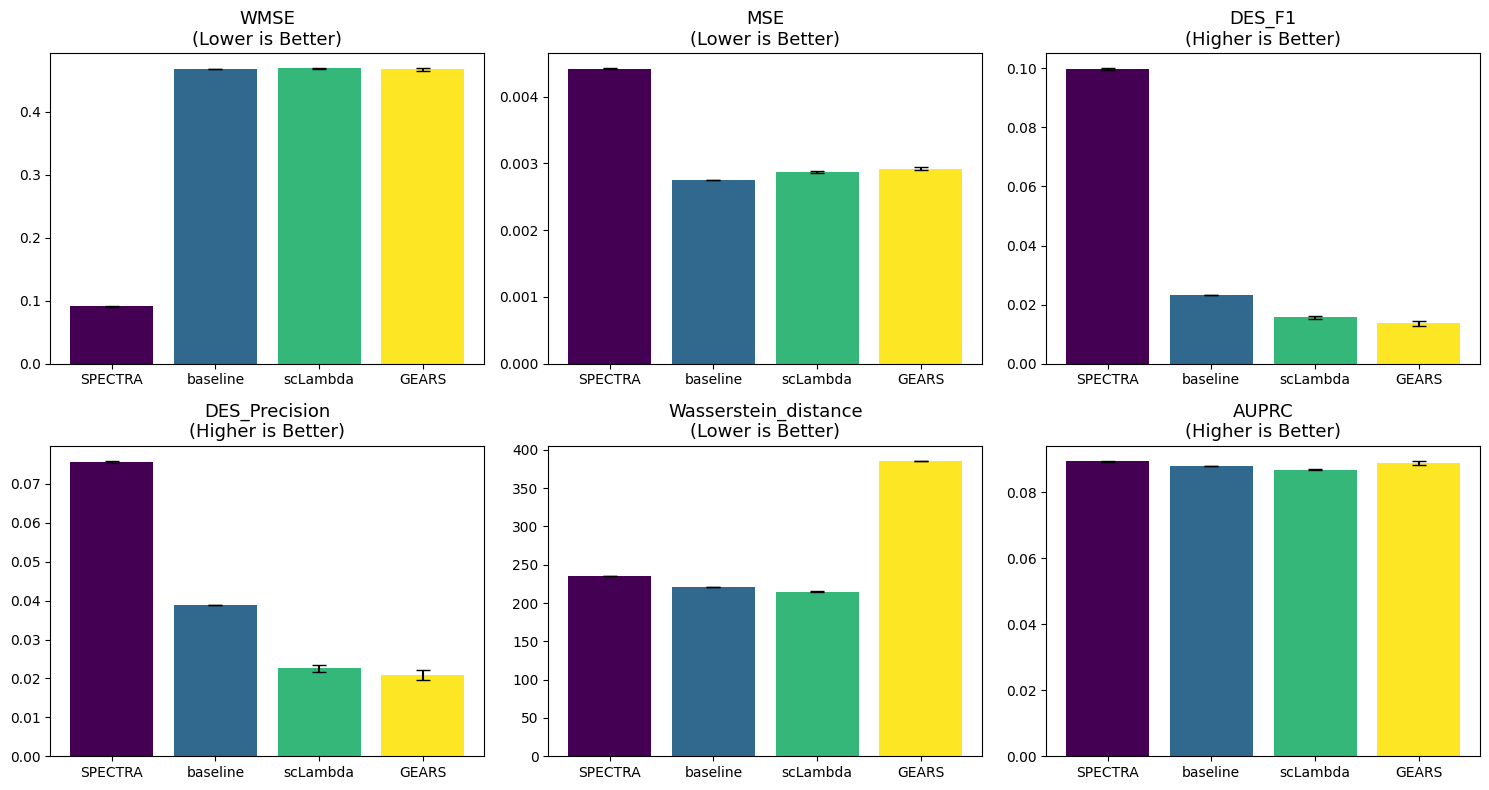

In [16]:
key_metrics = CORE_METRICS.keys()

# Set up the figure for this specific scenario
n_metrics = len(key_metrics)
ncols = math.ceil(n_metrics / 2)
nrows = 2

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.ravel() if hasattr(axes, "ravel") else [axes]


for ax, metric in zip(axes, key_metrics):
    # Filter for valid data within this scenario
    data = df[df[metric].notna() & (df['Status'] == 'OK')]
    if len(data) == 0: continue
    
    means = data.groupby('Model')[metric].mean().reindex(MODELS)
    stds = data.groupby('Model')[metric].std().reindex(MODELS)
    
    bars = ax.bar(MODELS, means, yerr=stds, capsize=5, color=[PALETTE[m] for m in MODELS], edgecolor='none', linewidth=0.8)
    
    # # Add value labels on bars
    # for bar, mean, std in zip(bars, means, stds):
    #     # Skip if the mean is NaN (e.g. model didn't complete this scenario)
    #     if pd.isna(mean): continue 
    #     ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.001,
    #             f'{mean:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    direction = 'Lower' if metric in ['WMSE', 'MSE', 'Wasserstein_distance'] else 'Higher'
    ax.set_title(f'{metric}\n({direction} is Better)', fontsize=13) #fontweight='bold'
    #ax.set_ylabel('Score')

# Add a Scenario-specific Super Title
#plt.suptitle(f'Key Metrics — {DATASET_SIZE} VCC Benchmark', fontsize=16, fontweight='bold')
plt.tight_layout()

plt.savefig(f'{PLOTS_FOLDER}/benchmark_mean_perfromances.pdf')
plt.show()

In [ ]:
# ════════════════════════════════════════════════════════════════════════════════════════════════════════════════
# Cell 8: Advanced Storytelling Visuals (Degradation & Win-Rates) NOTE: will be useful for multiple perturbations
# ════════════════════════════════════════════════════════════════════════════════════════════════════════════════

sns.set_theme(style='whitegrid', context='paper', font_scale=1.2)
# PALETTE = {'SPECTRA': '#2ecc71', 'baseline': '#3498db', 'scLAMBDA': '#e74c3c'}
# MODEL_ORDER = [m for m in ['SPECTRA', 'baseline', 'scLAMBDA'] if m in df_ok['Model'].unique()]

# Define metric directions
METRICS = [
    ('WMSE', 'lower'), 
    ('MSE', 'lower'), 
    # ('Pearson_distance', 'lower'),
    ('RobustDES_F1', 'higher'), 
    ('RobustDES_Precision', 'higher'), 
    ('AUPRC_Model', 'higher')
]

# PLOT 1: Zero-Shot Degradation Slopegraphs (Pointplots)
fig1, axes1 = plt.subplots(2, 4, figsize=(22, 10))
axes1 = axes1.flatten()

for i, (metric, title, direction) in enumerate(plot_metrics):
    ax = axes1[i]
    data = df_ok[df_ok[metric].notna()].copy()
    
    if data.empty: continue
        
    # Pointplot connects the means across Scenarios and draws confidence intervals
    sns.pointplot(
        data=data, x='Scenario', y=metric, hue='Model',
        hue_order=MODEL_ORDER, palette=PALETTE,
        dodge=0.1, markers=['o', 's', 'D'], capsize=.05, ax=ax, scale=1.2
    )
    
    #title = f"{metric}\n({'Lower' if direction == 'lower' else 'Higher'} is Better)"
    ax.set_title(title, fontweight='bold', fontsize=13)
    ax.set_xlabel('')
    ax.set_ylabel('Mean Score')
    
    if i == 0:
        ax.legend(title='Model', loc='best', fontsize=10)
    else:
        leg = ax.get_legend()
        if leg: leg.remove()

plt.suptitle('Model Robustness: The "Zero-Shot Penalty" (Scenario 1 ➔ Scenario 2)', fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()

# # Save Plot 1
# import os
# os.makedirs(f"{BASE_DIR}/SPECTRA/benchmark_results", exist_ok=True)
# fig_path1 = f"{BASE_DIR}/SPECTRA/benchmark_results/degradation_slopes.pdf"
# plt.savefig(fig_path1, dpi=300, bbox_inches='tight')
# plt.show()


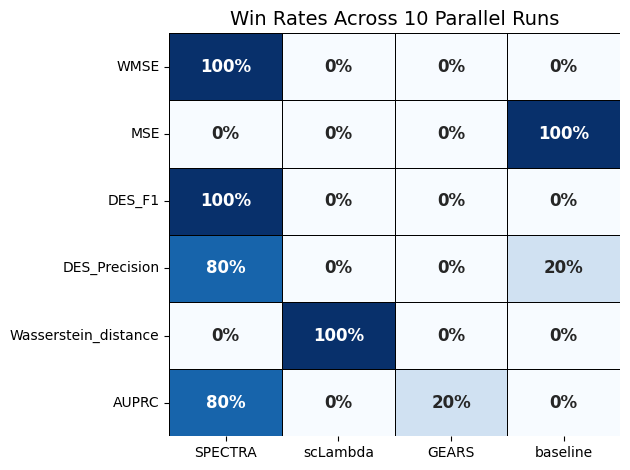

In [76]:

# ───────────────────────────────────────────────────────────────────────
# PLOT 2: The "Win-Rate" Head-to-Head Heatmap
# ───────────────────────────────────────────────────────────────────────
# Calculate: For each (Scenario, Run), who got 1st place?
win_records = []

for run in df_ok['Run'].unique():
    run_data = df_ok[df_ok['Run'] == run]
    
    # We need all models to be present to fairly judge a "win"
    if len(run_data['Model'].unique()) < len(MODELS): continue

    for metric in key_metrics:
        if run_data[metric].isna().all(): continue

        direction = 'Lower' if metric in ['WMSE', 'MSE', 'Wasserstein_distance'] else 'Higher'
        if direction == 'Lower':
            winner = run_data.loc[run_data[metric].idxmin()]['Model']
        else:
            winner = run_data.loc[run_data[metric].idxmax()]['Model']
            
        win_records.append({'Run': run, 'Metric': metric, 'Winner': winner})

wins_df = pd.DataFrame(win_records)

if not wins_df.empty:
        
    # Calculate Win Percentage
    win_counts = wins_df.groupby(['Metric', 'Winner']).size().unstack(fill_value=0)
    
    # Ensure all models are columns even if they won 0 times
    for m in MODELS:
        if m not in win_counts: win_counts[m] = 0
            
    win_pct = (win_counts.div(win_counts.sum(axis=1), axis=0) * 100).fillna(0)
    
    # Reorder metrics and models for consistency
    win_pct = win_pct.reindex([m for m in key_metrics]).reindex(columns=MODELS).fillna(0)
    
    ax=sns.heatmap(
        win_pct, annot=True, fmt=".0f", cmap="Blues", cbar=False,
        linewidths=0.5, linecolor='black', annot_kws={"size": 12, "weight": "bold"}
    )
    
    plt.title(f"Win Rates Across 10 Parallel Runs", fontsize=14)
    plt.ylabel('')
    plt.xlabel('')
    
    # Add % sign to annotations
    for t in ax.texts: t.set_text(t.get_text() + "%")

    plt.tight_layout()
    plt.savefig(f'{PLOTS_FOLDER}/win_rates.pdf')
    plt.show()
else:
    print("Could not compute win-rates (make sure all models completed the same runs).")

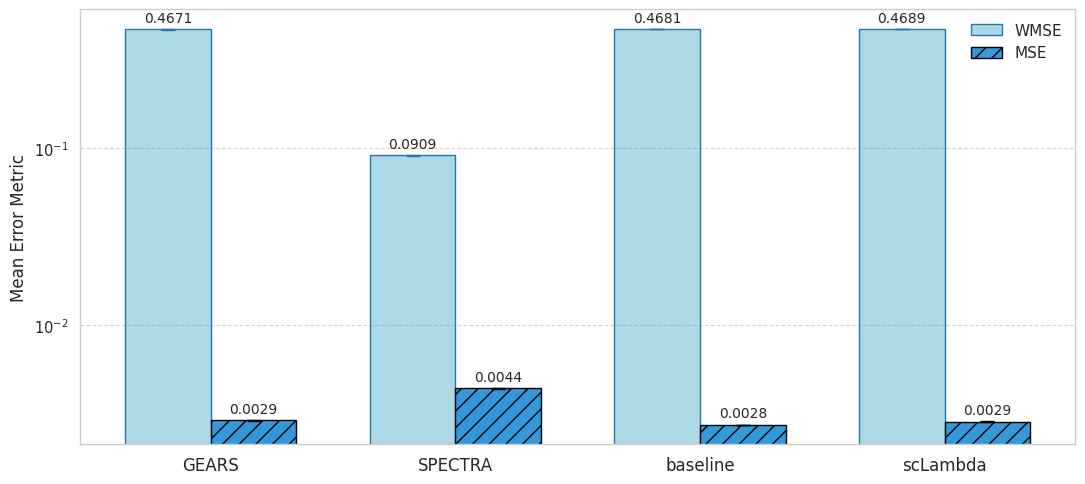

In [49]:
# 1. Filter out errors and compute both mean and std per model
df_clean = df[df['Status'] == 'OK']
df_stats = df_clean.groupby('Model')[['WMSE', 'MSE']].agg(['mean', 'std']).reset_index()

# Flatten the multi-index columns for easier programming
df_stats.columns = ['Model', 'WMSE_mean', 'WMSE_std', 'MSE_mean', 'MSE_std']

# Extract variables for plotting
models = df_stats['Model'].tolist()
wmse_means = df_stats['WMSE_mean'].tolist()
wmse_stds = df_stats['WMSE_std'].tolist()
mse_means = df_stats['MSE_mean'].tolist()
mse_stds = df_stats['MSE_std'].tolist()

# 2. Set bar positions and widths
x = np.arange(len(models))
width = 0.35  

fig, ax = plt.subplots(figsize=(11, 5))

# 3. Render side-by-side bars with yerr (Standard Deviation)
# Light blue solid column for WMSE
bars_wmse = ax.bar(
    x - width/2, wmse_means, width, 
    yerr=wmse_stds, capsize=5, error_kw={'ecolor': '#1f77b4', 'elinewidth': 1.5},
    label='WMSE', color='#add8e6', edgecolor='#1f77b4', linewidth=1.
)

# Barred/hatched blue column for MSE
bars_mse = ax.bar(
    x + width/2, mse_means, width, 
    yerr=mse_stds, capsize=5, error_kw={'ecolor': 'black', 'elinewidth': 1.5},
    label='MSE', color='#3498db', edgecolor='black', linewidth=1., hatch='//'
)

# 4. Formatting and labeling
# ax.set_title('Model Performance Comparison: WMSE vs MSE (Mean ± SD)', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Mean Error Metric', fontsize=12)
ax.set_xticks(x)
ax.set_yscale('log')
ax.set_xticklabels(models, fontsize=12)
ax.legend(fontsize=11, loc='upper right', frameon=False)

# Add subtle grid lines behind the bars
ax.grid(False)
# ax.grid(axis='y', color='gray', linestyle='dashed', alpha=0.3)

# Add value annotations on top of the bars dynamically
def add_labels(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

add_labels(bars_wmse)
add_labels(bars_mse)
plt.tight_layout()
plt.grid(True, axis='y', color='gray', linestyle='--', linewidth=0.8, alpha=0.33)
ax = plt.gca(); ax.set_axisbelow(False) # ensures grid is drawn on top
plt.savefig(f'{PLOTS_FOLDER}/wmse_vs_mse.pdf', bbox_inches='tight')
plt.show()

In [16]:
from centroid_accuracy import calculate_centroid_accuracies

def get_real_centroids(adata):
    """
    Computes ground-truth centroids.
    Returns a DataFrame with perturbations as the index and genes as columns.
    """
    # Extract dense expression matrix
    expr_matrix = adata.X.toarray() if hasattr(adata.X, 'toarray') else adata.X
        
    df = pd.DataFrame(expr_matrix, columns=adata.var_names)
    df['perturbation'] = adata.obs['target_gene'].values
    
    # Group by perturbation and compute the mean
    # This automatically sets 'perturbation' as the index
    return df.groupby('perturbation').mean()

def get_pred_centroids(adata, method_name):
    """
    Computes predicted centroids.
    Returns a DataFrame with a MultiIndex (perturbation, method) and genes as columns.
    """
    # Extract dense expression matrix
    expr_matrix = adata.X.toarray() if hasattr(adata.X, 'toarray') else adata.X
        
    df = pd.DataFrame(expr_matrix, columns=adata.var_names)
    df['perturbation'] = adata.obs['target_gene'].values
    
    centroids = df.groupby('perturbation').mean()
    
    # Add the method level to create the MultiIndex
    centroids['method'] = method_name
    centroids = centroids.set_index('method', append=True)
    
    return centroids

# Build the ground-truth DataFrame
adata_true = sc.read_h5ad(GT_PATH)
df_real = get_real_centroids(adata_true)

all_pred_centroids = []

for model in MODELS:
    run_centroids_list = []
    
    for run in RUNS:
        pred_path = get_h5ad_path(model, run) 
        adata_pred = sc.read_h5ad(pred_path)
        run_centroids = get_pred_centroids(adata_pred, model)
        run_centroids_list.append(run_centroids)
        
    # Average the centroids across all 10 runs for this specific model.
    # pd.concat stacks them, and groupby(level=0).mean() computes the average per perturbation.
    avg_model_centroids = pd.concat(run_centroids_list).groupby(level=0).mean()
    
    # Add the method level to create the MultiIndex format needed for the evaluator
    avg_model_centroids['method'] = model
    avg_model_centroids = avg_model_centroids.set_index('method', append=True)
    
    # Store the averaged MultiIndex dataframe for this model
    all_pred_centroids.append(avg_model_centroids)

# Concatenate all averaged models into the final single DataFrame
combined_centroids_df = pd.concat(all_pred_centroids)

# Calculate final accuracies
scores_df = calculate_centroid_accuracies(combined_centroids_df, df_real)
scores_df


,SPECTRA,baseline,scLambda,GEARS
perturbation,,,,
AKT2,0.526316,0.421053,0.421053,0.473684
BIRC2,0.473684,0.473684,0.421053,0.421053
C1QBP,0.631579,0.368421,0.368421,0.368421
CALM3,1.000000,0.842105,0.842105,0.842105
CLDN6,1.000000,0.315789,0.315789,0.315789
DAXX,0.736842,0.631579,0.631579,0.631579
ETV4,0.157895,0.157895,0.157895,0.157895
FDPS,0.052632,0.052632,0.052632,0.052632
HSBP1,0.210526,0.210526,0.210526,0.210526


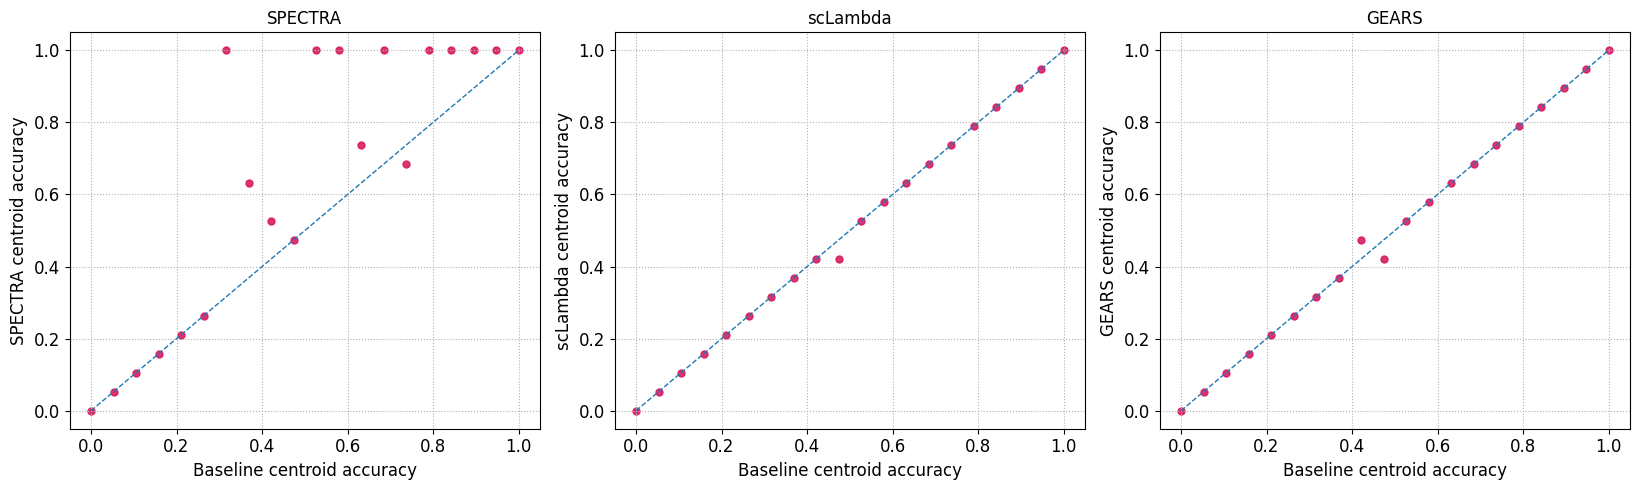

In [77]:
########################################################################################################
# code to plot comparison of baseline centroid accuracy vs the other models (GEARS, scLambda, SPECTRA) #
########################################################################################################

fontsize=12
def plot_gene_acc_comparison(ax, x_df, y_df, s=10):
    x = x_df
    y = y_df
    ax.scatter(x, y, s=s, color='#D81B60', alpha=0.9)  

models_to_compare = [model for model in MODELS if model!='baseline']
fig, axes = plt.subplots(1, 3, figsize=(5.5 * len(models_to_compare), 5))
if len(models_to_compare) == 1:
    axes = [axes]

for ax, method in zip(axes, models_to_compare):
    plot_gene_acc_comparison(ax,
                            scores_df['baseline'],
                            scores_df[method],
                            s=25)

    ax.plot([0, 1], [0, 1], linestyle="--", lw=1)
    ax.grid(linestyle=":")
    ax.set_xlabel("Baseline centroid accuracy", fontsize=fontsize)
    ax.set_ylabel(f"{method} centroid accuracy", fontsize=fontsize)
    ax.tick_params(labelsize=fontsize)
    ax.set_title(method, fontsize=fontsize)

plt.tight_layout()
plt.savefig(f'{PLOTS_FOLDER}/centroid_accuracy_vs_baseline.pdf', bbox_inches='tight')


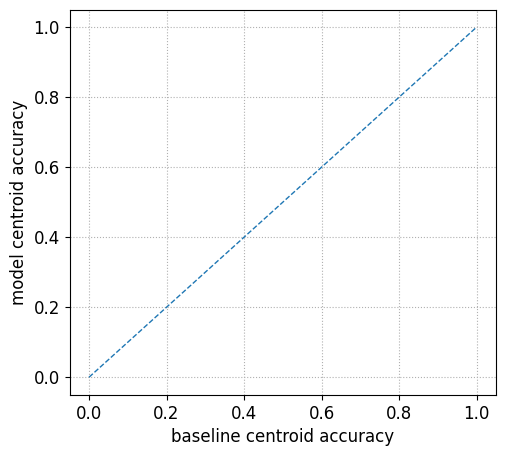

In [33]:

fontsize=12
# ds = scores_df_all['dataset'].unique()

def plot_gene_acc_comparison(x_df, y_df, s=10):
    x = x_df
    y = y_df
    plt.scatter(x, y, s=s, color='#D81B60', alpha=0.5)  


method = 'SPECTRA'


plt.figure(figsize=(5.5, 5))
# plot_gene_acc_comparison(scores_df['baseline'],
#                          scores_df[method],
#                          s=25)

# plt.legend(fontsize=fontsize)
plt.plot([0, 1], [0, 1], linestyle='dashed', lw=1.)  # Line from (0,0) to (1,1)
plt.grid(linestyle='dotted')
plt.xlabel('baseline centroid accuracy', fontsize=fontsize)
plt.ylabel(f'model centroid accuracy', fontsize=fontsize);
# plt.title(term.split('(')[0][:-1], fontsize=fontsize)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize);
plt.savefig(f'{PLOTS_FOLDER}/centroid_accuracy_explain_image.pdf', bbox_inches='tight');


In [81]:
df[df['Status'] == 'OK'].drop(columns=['Status'], errors='ignore').round(4).to_csv(RESULTS_CSV)